# Closed-Loop Doppler Pre-Fit Residuals of GRAIL-A using ODF files

This notebook computes pre-fit residuals of GRAIL-A using closed-loop Doppler observations of GRAIL-A, retrieved from ODF files, as presented in Fig. 3 of the poster.

For a description of the general workflow to obtain pre-fit residuals see the [mro_doppler_prefits.ipynb](mro_doppler_prefits.ipynb) notebook.
The workflow in this notebook only deviates from the MRO workflow in the way the antenna reference points are retrieved and set in the `ObservationCollection`, see [Antenna Reference Points](#antenna-reference-points).

## Required Data Files

The following data files are required to run the example.
All data files should be placed in a `data/GRAIL-A/` directory relative to this notebook.

### Kernels
All following kernels were retrieved from the [GRAIL SPICE Data Archive](https://naif.jpl.nasa.gov/pub/naif/pds/data/grail-l-spice-6-v1.0/grlsp_1000/data/):
- `fk`:
  - `grail_v07.tf`
- `sclk`
  - `gra_sclkscet_00014.tsc`
- `ck`
  - `gra_rec_120326_120401.bc`
  - `gra_rec_120402_120408.bc`
  - `gra_rec_120409_120415.bc`
  - `gra_rec_120416_120422.bc`
  - `gra_rec_120423_120429.bc`
  - `gra_rec_120430_120506.bc`
- `spk`
  - `grail_120301_120529_sci_v02.bsp`

These should be placed in `data/GRAIL-A/kernels/{kernel-type}/{file-name}`.

### ODF and Ancillary Files
All ODF and ancillary files are retrieved from the [PDS Geosciences Node](https://pds-geosciences.wustl.edu/grail/grail-l-rss-2-edr-v1/grail_0201/):
- `odf`
  - `gralugf2012_093_0400smmmv1.odf`
  - `gralugf2012_094_0931smmmv1.odf`
  - `gralugf2012_095_0435smmmv1.odf`
  - `gralugf2012_096_0459smmmv1.odf`
  - `gralugf2012_097_0235smmmv1.odf`
  - `gralugf2012_099_0407smmmv1.odf`
  - `gralugf2012_100_0540smmmv1.odf`
  - `gralugf2012_101_0235smmmv1.odf`
  - `gralugf2012_102_0358smmmv1.odf`
  - `gralugf2012_103_0145smmmv1.odf`
  - `gralugf2012_105_0352smmmv1.odf`
  - `gralugf2012_107_0405smmmv1.odf`
  - `gralugf2012_108_0450smmmv1.odf`
  - `gralugf2012_109_1227smmmv1.odf`
  - `gralugf2012_111_1332smmmv1.odf`
  - `gralugf2012_114_0900smmmv1.odf`
  - `gralugf2012_117_0300smmmv1.odf`
  - `gralugf2012_119_0545smmmv1.odf`
  - `gralugf2012_121_0155smmmv1.odf`
- `asc`
  - `vgs1b_2012_04_01_a_04.asc`
  - `vgs1b_2012_04_02_a_04.asc`
  - `vgs1b_2012_04_03_a_04.asc`
  - `vgs1b_2012_04_04_a_04.asc`
  - `vgs1b_2012_04_05_a_04.asc`
  - `vgs1b_2012_04_06_a_04.asc`
  - `vgs1b_2012_04_07_a_04.asc`
  - `vgs1b_2012_04_08_a_04.asc`
  - `vgs1b_2012_04_09_a_04.asc`
  - `vgs1b_2012_04_10_a_04.asc`
  - `vgs1b_2012_04_11_a_04.asc`
  - `vgs1b_2012_04_12_a_04.asc`
  - `vgs1b_2012_04_13_a_04.asc`
  - `vgs1b_2012_04_14_a_04.asc`
  - `vgs1b_2012_04_15_a_04.asc`
  - `vgs1b_2012_04_16_a_04.asc`
  - `vgs1b_2012_04_17_a_04.asc`
  - `vgs1b_2012_04_18_a_04.asc`
  - `vgs1b_2012_04_19_a_04.asc`
  - `vgs1b_2012_04_20_a_04.asc`
  - `vgs1b_2012_04_21_a_04.asc`
  - `vgs1b_2012_04_22_a_04.asc`
  - `vgs1b_2012_04_23_a_04.asc`
  - `vgs1b_2012_04_24_a_04.asc`
  - `vgs1b_2012_04_25_a_04.asc`
  - `vgs1b_2012_04_26_a_04.asc`
  - `vgs1b_2012_04_27_a_04.asc`
  - `vgs1b_2012_04_28_a_04.asc`
  - `vgs1b_2012_04_29_a_04.asc`
  - `vgs1b_2012_04_30_a_04.asc`
- `tro`
  - `grxlugf2012_061_2012_092.tro`
  - `grxlugf2012_092_2012_122.tro`
- `ion`
  - `gralugf2012_061_2012_092.ion`
  - `gralugf2012_092_2012_122.ion`

These should be placed in `data/GRAIL-A/{file-type}/{file-name}`.

In [1]:
from tudatpy.data_input.environment_data import spice

spice.load_standard_kernels()

In [2]:
from pathlib import Path

sc_name = "GRAIL-A"
sc_id = 177

mission_file_directory = Path(f"data/{sc_name}")
mission_output_directory = Path(f"output/{sc_name}")

In [3]:
kernels_directory = mission_file_directory / "kernels"

frames_def_kernel = kernels_directory / "fk" / "grail_v07.tf"
sclk_kernel = kernels_directory / "sclk" / "gra_sclkscet_00014.tsc"
orientation_file_names = [
    "gra_rec_120326_120401.bc",
    "gra_rec_120402_120408.bc",
    "gra_rec_120409_120415.bc",
    "gra_rec_120416_120422.bc",
    "gra_rec_120423_120429.bc",
    "gra_rec_120430_120506.bc",
]
orientation_kernels = [kernels_directory / "ck" / f for f in orientation_file_names]
trajectory_kernels = [
    kernels_directory / "spk" / "grail_120301_120529_sci_v02.bsp",
]

# Load frame definition file (required for HGA and spacecraft-fixed frames definition)
spice.load_kernel(frames_def_kernel.as_posix())
# Load SC clock file (required for conversion between SCLK and UTC, used when retrieving SC orientation)
spice.load_kernel(sclk_kernel.as_posix())

# Load orientation kernels
for orientation_file in orientation_kernels:
    spice.load_kernel(orientation_file.as_posix())
# Load trajectory kernels
for trajectory_file in trajectory_kernels:
    spice.load_kernel(trajectory_file.as_posix())


In [4]:
from tudatpy.data_input.tracking_data.odf import read_odf_data

odf_file_directory = mission_file_directory / "odf"

odf_file_names = [
    "gralugf2012_093_0400smmmv1.odf",
    "gralugf2012_094_0931smmmv1.odf",
    "gralugf2012_095_0435smmmv1.odf",
    "gralugf2012_096_0459smmmv1.odf",
    "gralugf2012_097_0235smmmv1.odf",
    "gralugf2012_099_0407smmmv1.odf",
    "gralugf2012_100_0540smmmv1.odf",
    "gralugf2012_101_0235smmmv1.odf",
    "gralugf2012_102_0358smmmv1.odf",
    "gralugf2012_103_0145smmmv1.odf",
    "gralugf2012_105_0352smmmv1.odf",
    "gralugf2012_107_0405smmmv1.odf",
    "gralugf2012_108_0450smmmv1.odf",
    "gralugf2012_109_1227smmmv1.odf",
    "gralugf2012_111_1332smmmv1.odf",
    "gralugf2012_114_0900smmmv1.odf",
    "gralugf2012_117_0300smmmv1.odf",
    "gralugf2012_119_0545smmmv1.odf",
    "gralugf2012_121_0155smmmv1.odf",
]
odf_files = [(mission_file_directory / "odf" / f).as_posix() for f in odf_file_names]
tracking_data, tracking_supplementary_data = read_odf_data(
    odf_files,
    spacecraft_name=sc_name,
)

In [5]:
# Create default body settings for celestial bodies
from tudatpy.dynamics import environment_setup

bodies_to_create = [
    "Earth",
    "Sun",
    "Moon",
]
global_frame_origin = "SSB"
global_frame_orientation = "ECLIPJ2000"


start_time = min(min(t_data.epochs) for t_data in tracking_data) - 86400
end_time = max(max(t_data.epochs) for t_data in tracking_data) + 86400

body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    global_frame_origin,
    global_frame_orientation,
)

# Modify Earth default settings
body_settings.get(
    "Earth"
).rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006,
    global_frame_orientation,
)
# since we defined the Earth rotation model as GCRS to ITRS, we need to set the gravity field reference frame to ITRS as well
body_settings.get("Earth").gravity_field_settings.associated_reference_frame = "ITRS"

body_settings.get(
    "Earth"
).shape_settings = environment_setup.shape.oblate_spherical_spice()
body_settings.get(
    "Earth"
).ground_station_settings = environment_setup.ground_station.dsn_stations()


In [6]:
from tudatpy.dynamics import environment_setup

body_settings.add_empty_settings(sc_name)

# Retrieve translational ephemeris from SPICE
body_settings.get(
    sc_name
).ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    global_frame_origin,
    global_frame_orientation,
)

# Retrieve rotational ephemeris from SPICE
body_settings.get(
    sc_name
).rotation_model_settings = environment_setup.rotation_model.spice(
    global_frame_orientation, f"{sc_name}_SPACECRAFT"
)


In [7]:
# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)

bodies.get(sc_name).system_models.set_default_transponder_turnaround_ratio_function()

In [8]:
from tudatpy.estimation import observations

observation_collection = observations.create_observation_collection_from_tracking_data(
    tracking_data, bodies
)
observations.set_tracking_supplementary_data_in_bodies(
    bodies, tracking_supplementary_data
)

In [9]:
compressed_observations = observations.create_compressed_doppler_collection(
    observation_collection, 60
)

## Antenna Reference Points

In [10]:
import numpy as np
from tudatpy.data_input.environment_data.missions.grail import grail_antenna_file_reader
from tudatpy.estimation.observable_models_setup import links

antenna_switch_file_names = [
    "vgs1b_2012_04_01_a_04.asc",
    "vgs1b_2012_04_02_a_04.asc",
    "vgs1b_2012_04_03_a_04.asc",
    "vgs1b_2012_04_04_a_04.asc",
    "vgs1b_2012_04_05_a_04.asc",
    "vgs1b_2012_04_06_a_04.asc",
    "vgs1b_2012_04_07_a_04.asc",
    "vgs1b_2012_04_08_a_04.asc",
    "vgs1b_2012_04_09_a_04.asc",
    "vgs1b_2012_04_10_a_04.asc",
    "vgs1b_2012_04_11_a_04.asc",
    "vgs1b_2012_04_12_a_04.asc",
    "vgs1b_2012_04_13_a_04.asc",
    "vgs1b_2012_04_14_a_04.asc",
    "vgs1b_2012_04_15_a_04.asc",
    "vgs1b_2012_04_16_a_04.asc",
    "vgs1b_2012_04_17_a_04.asc",
    "vgs1b_2012_04_18_a_04.asc",
    "vgs1b_2012_04_19_a_04.asc",
    "vgs1b_2012_04_20_a_04.asc",
    "vgs1b_2012_04_21_a_04.asc",
    "vgs1b_2012_04_22_a_04.asc",
    "vgs1b_2012_04_23_a_04.asc",
    "vgs1b_2012_04_24_a_04.asc",
    "vgs1b_2012_04_25_a_04.asc",
    "vgs1b_2012_04_26_a_04.asc",
    "vgs1b_2012_04_27_a_04.asc",
    "vgs1b_2012_04_28_a_04.asc",
    "vgs1b_2012_04_29_a_04.asc",
    "vgs1b_2012_04_30_a_04.asc",
]
antennas_switch_files = [
    (mission_file_directory / "asc" / f).as_posix() for f in antenna_switch_file_names
]

antenna_switch_times = []
antenna_switch_positions = []
for file in antennas_switch_files:
    switch_times, switch_positions = grail_antenna_file_reader(file)
    antenna_switch_times += switch_times
    antenna_switch_positions += switch_positions

# Reconstruct dictionary containing the antenna switch history (including the GRAIL-fixed position of the relevant antenna at
# initial and final times)
antenna_switch_history = {}
antenna_switch_history[start_time] = np.array(antenna_switch_positions[0:3])
for k in range(len(antenna_switch_times)):
    antenna_switch_history[antenna_switch_times[k]] = np.array(
        antenna_switch_positions[k * 3 : (k + 1) * 3]
    )
antenna_switch_history[end_time] = np.array(antenna_switch_positions[-3:])

# Set GRAIL's reference point position to follow the antenna switch history (the antennas' positions should be provided in the
# spacecraft-fixed frame).
compressed_observations.set_reference_points(
    bodies,
    antenna_switch_history,
    sc_name,
    links.LinkEndType.reflector1,
)

In [11]:
from tudatpy.estimation import observable_models_setup, observations, observations_setup

relativistic_lt_correction = observable_models_setup.light_time_corrections.approximated_second_order_relativistic_light_time_correction(
    ["Sun"]
)

# the default seasonal model is already applied internally, here we only need to provide the monthly adjustment files
tro_file_names = ["grxlugf2012_061_2012_092.tro", "grxlugf2012_092_2012_122.tro"]
tro_files = [(mission_file_directory / "tro" / f).as_posix() for f in tro_file_names]
tropospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_tropospheric_light_time_correction(
    tro_files,
)

ion_file_names = ["gralugf2012_061_2012_092.ion", "gralugf2012_092_2012_122.ion"]
ion_files = [(mission_file_directory / "ion" / f).as_posix() for f in ion_file_names]
spacecraft_name_per_id = {sc_id: sc_name}
ionospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_ionospheric_light_time_correction(
    ion_files, spacecraft_name_per_id
)

doppler_lt_corrections = [
    relativistic_lt_correction,
    tropospheric_lt_correction,
    ionospheric_lt_correction,
]


In [12]:
from tudatpy.estimation.observable_models_setup import model_settings

doppler_link_definitions = compressed_observations.link_definitions_per_observable[
    model_settings.ObservableType.dsn_n_way_averaged_doppler_type
]
observable_model_settings = [
    model_settings.dsn_n_way_doppler_averaged(link_definition, doppler_lt_corrections)
    for link_definition in doppler_link_definitions
]

observation_simulators = (
    observations_setup.observations_simulation_settings.create_observation_simulators(
        observable_model_settings, bodies
    )
)

In [13]:
# Compute and set residuals in the compressed observation collection
observations.compute_residuals_and_dependent_variables(
    compressed_observations, observation_simulators, bodies
)


Text(0, 0.5, 'Doppler residuals [Hz]')

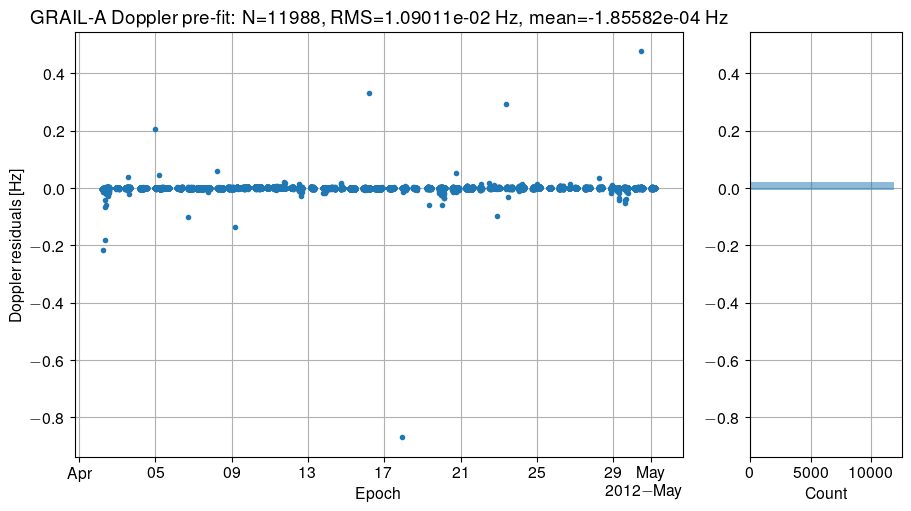

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from tudatpy.astro.time_representation import DateTime

import plotting_utils as plt_utils

prefit_observation_times_dt = [
    DateTime.from_epoch(t).to_python_datetime()
    for t in compressed_observations.get_concatenated_observation_times()
]
prefit_residuals = compressed_observations.get_concatenated_residuals()
prefit_N_obs = len(prefit_residuals)
prefit_RMS = np.sqrt(np.square(prefit_residuals).mean())
prefit_mean = prefit_residuals.mean()


fig, (ax, ax_hist) = plt_utils.create_residual_timeseries_with_histogram_figure()

ax.plot(
    prefit_observation_times_dt,
    prefit_residuals,
    ".",
)
ax_hist.hist(
    prefit_residuals,
    bins=50,
    alpha=0.5,
    orientation="horizontal",
)

ax.set_title(
    f"{sc_name} Doppler pre-fit: N={prefit_N_obs}, RMS={prefit_RMS:.5e} Hz, mean={prefit_mean:.5e} Hz"
)

ax.set_ylabel("Doppler residuals [Hz]")


In [15]:
# create a new observation collection to keep all original observations
filtered_observations = observations.create_new_observation_collection(
    compressed_observations
)

residual_threshold = 0.02  # abs(residuals) > 0.02 Hz
filter_residuals = observations.observations_processing.observation_filter(
    observations.observations_processing.ObservationFilterType.residual_filtering,
    residual_threshold,
)

filtered_observations.filter_observations(filter_residuals)
filtered_observations.remove_empty_observation_sets()


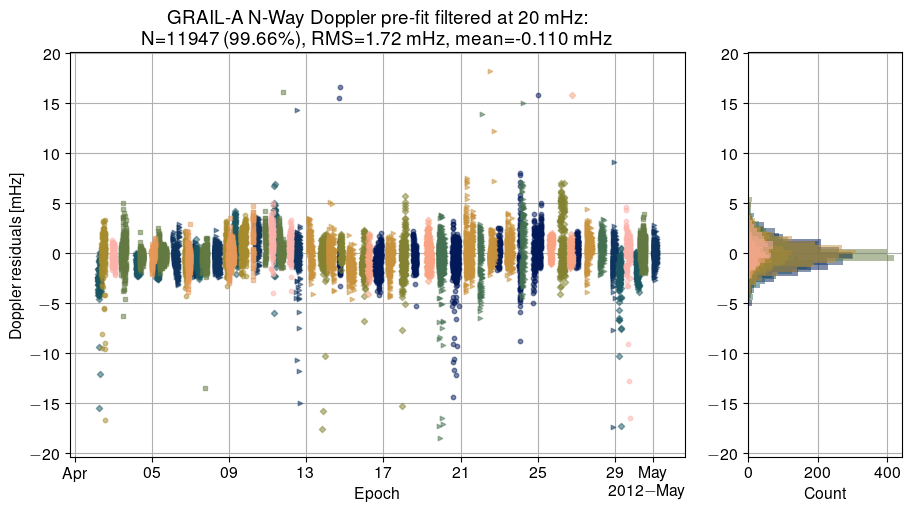

In [16]:
import plotting_utils as plt_utils

with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations, add_legend=False
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)
plt_utils.save_figure(
    fig,
    mission_output_directory
    / f"{sc_name}_doppler_prefits_filtered_{residual_threshold:.2f}Hz.png",
)

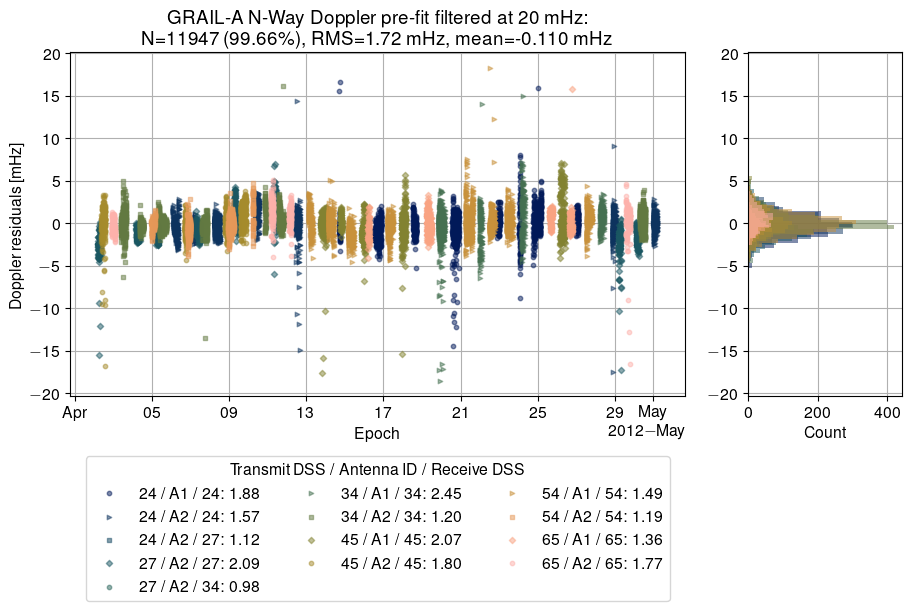

In [17]:
import plotting_utils as plt_utils

grail_link_label_formatter = lambda link_definition: (
    f"{link_definition.link_ends[links.LinkEndType.transmitter].station_name[-2:]} / A{link_definition.link_ends[links.LinkEndType.reflector1].station_name[-1]} / {link_definition.link_ends[links.LinkEndType.receiver].station_name[-2:]}"
)

with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations,
            figsize=(9, 6),
            add_legend=False,
            link_label_formatter=grail_link_label_formatter,
        )
    )

ax.legend(
    ncols=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    title="Transmit DSS / Antenna ID / Receive DSS",
)

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)